This notebook demonstrates 3 key technical concepts in a single execution line:

- Detection (OpenCV): Locate the face box

- Extraction (DeepFace): Generate the numerical array

- Verification: Output the vector footprint

Import Libraries

In [1]:
import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace

I0000 00:00:1780132072.729110   17570 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780132072.729927   17570 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780132072.808478   17570 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780132074.691336   17570 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Load the XML Cascade File

In [2]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

Load Image

In [3]:
img = cv2.imread("images/image_4.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Find Number of Faces

In [4]:
faces = face_cascade.detectMultiScale(gray, scaleFactor = 1.1, minNeighbors = 5)
print(f"Detected {len(faces)} face(s) in this image.")

Detected 1 face(s) in this image.


Draw Bounding Box

In [5]:
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 4)

Display Image

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

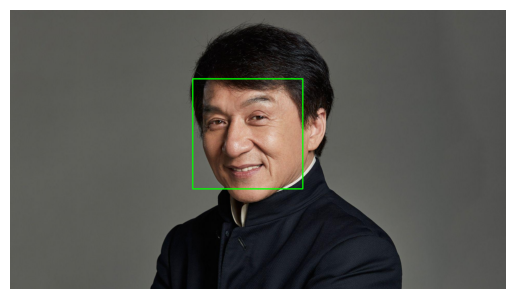

In [6]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

Pre-Loading the ArcFace Model Architecture

In [7]:
DeepFace.build_model("ArcFace")

E0000 00:00:1780132088.055167   17570 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Pass Coordinates to DeepFace to Extract the Vector

In [8]:
embedding_objs = DeepFace.represent(
    img_path = "images/image_18.jpg",
    model_name = "ArcFace",
    detector_backend = "skip"
)

raw_vector = embedding_objs[0]["embedding"]

print("Vector Extraction Successful")
print(f"Total Vector Dimensions: {len(raw_vector)}")
print(f"Sample Floats (First 5 Dimensions): {raw_vector[:5]}")

Vector Extraction Successful
Total Vector Dimensions: 512
Sample Floats (First 5 Dimensions): [-0.1407071352005005, 0.4150230586528778, -0.07209156453609467, -0.37324583530426025, -0.006092412397265434]
